# Código de investigación — Análisis estadístico

**Estudio:** efecto del tipo de modelo abierto de aprendizaje sobre autoeficacia, selección de subtópicos y desempeño.

**Grupos (factor principal):**

| Grupo | Descripción |
|---|---|
| `OLM` | Open Learner Model: el estudiante ve solo su propio progreso. Sin comparación social. |
| `OSLM` | Open Social Learner Model: además ve el progreso del grupo (comparación social). |
| `OSLM+VP` | OSLM + mensajes motivacionales / virtual peer. |

**Contrastes planificados** (en lugar de tratar `grupo` como factor nominal suelto):

- `comparacionOSLM` = 1 para OSLM y OSLM+VP, 0 para OLM → **efecto de exponer comparación social** (OSLM vs OLM).
- `comparacionOSLMVP` = 1 solo para OSLM+VP → **efecto adicional del mensaje motivacional** (OSLM+VP vs OSLM).

**Segundo factor: dirección de la comparación** (`direccion`): `arriba` (upward: el estudiante está por debajo del promedio del grupo), `abajo` (downward), `igual`, `no` (no se mostró comparación — solo OLM en `dfSecuencia`).

---
### Estructura del notebook
0. Configuración, carga de datos y diccionario de variables
1. Funciones auxiliares de análisis
2. Descriptivos por grupo
3. **Pregunta 2** — Autoeficacia: cambio según grupo y según dirección de comparación
4. **Pregunta 3.1** — Selección de subtópicos con comparación social (OSLM vs OSLM+VP)
5. **Pregunta 3.2** — Desempeño en la actividad (global y por dirección)
6. Gráficos exploratorios de desempeño
7. **Revisión inversa** — matriz de screening variable × factor (qué cambió y merece atención)
8. Síntesis de hallazgos y de correcciones aplicadas
9. **Qué es publicable** — qué podemos afirmar y sostener
10. Apéndice — construcción histórica de variables (referencia, no ejecutable con los datos actuales)

## 0. Configuración, carga de datos y diccionario de variables

### 0.1 Imports

In [ ]:
import os, warnings, itertools
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
RNG = 123


In [2]:
DATA_DIR = r"C:\Users\joaqu\OneDrive\Desktop\MAGISTER DEFINITIVO\tesis"

dfUsuario        = pd.read_excel(os.path.join(DATA_DIR, "dfUsuario.xlsx"))       # 1 fila = 1 usuario (acumulado)
dfSegmento       = pd.read_excel(os.path.join(DATA_DIR, "dfSegmento.xlsx"))      # 1 fila = transición entre polls dentro de un tópico
df_1_to_2        = pd.read_excel(os.path.join(DATA_DIR, "df_1_to_2.xlsx"))       # subconjunto: transición poll 1 -> 2
df_2_to_3        = pd.read_excel(os.path.join(DATA_DIR, "df_2_to_3.xlsx"))       # subconjunto: transición poll 2 -> 3
dfNivelEjercicio = pd.read_excel(os.path.join(DATA_DIR, "dfNivelEjercicio.xlsx"))# 1 fila = un bloque de ejercicio completado

for nombre, d in [("dfUsuario", dfUsuario), ("dfSegmento", dfSegmento),
                  ("df_1_to_2", df_1_to_2), ("df_2_to_3", df_2_to_3),
                  ("dfNivelEjercicio", dfNivelEjercicio)]:
    print(f"{nombre:18s} {d.shape[0]:5d} filas x {d.shape[1]:2d} cols | "
          f"{d['userid'].nunique():3d} usuarios | grupos: {d['grupo_intervencion'].value_counts().to_dict()}")

dfUsuario            181 filas x 47 cols | 181 usuarios | grupos: {'OSLM+VP': 71, 'OLM': 59, 'OSLM': 51}
dfSegmento           809 filas x 17 cols |  86 usuarios | grupos: {'OSLM+VP': 275, 'OSLM': 272, 'OLM': 262}
df_1_to_2            267 filas x 17 cols |  82 usuarios | grupos: {'OSLM+VP': 90, 'OSLM': 90, 'OLM': 87}
df_2_to_3            128 filas x 17 cols |  57 usuarios | grupos: {'OSLM+VP': 48, 'OLM': 46, 'OSLM': 34}
dfNivelEjercicio    5017 filas x 28 cols | 185 usuarios | grupos: {'OLM': 1899, 'OSLM+VP': 1647, 'OSLM': 1471}


### 0.3 Diccionario de variables (resumen)

**`dfUsuario`** (nivel usuario, acumulado):

| Variable | Significado |
|---|---|
| `primer_pollValue`, `autoeficacia_general` | autoeficacia (0–100): primera medición y promedio |
| `total_attempts`, `first_attempts_correct`, `unique_steps` | intentos totales, aciertos a la primera, pasos únicos |
| `prop_first_attempts_correct` = `performance` | proporción de pasos resueltos a la primera (desempeño) |
| `Tasa_exito`, `tasa_hints` | tasa de éxito y de uso de pistas |
| `progreso_inicial`, `progreso_inicial_grupo` | progreso propio / del grupo al inicio |
| `casos`, `casos_comparacion_arriba/abajo` | nº de bloques; nº con comparación upward / downward |
| `porce_topicos_arriba/abajo` | proporción de tópicos con comparación upward / downward |
| `performance_arriba/abajo` | desempeño en bloques con comparación upward / downward |
| `preferencia_casos_comparacion`, `preferencia_casos_uw` | preferencia por casos con comparación / upward (rango −1..1) |
| `*_comparacion_arriba/abajo` | métricas restringidas a bloques con esa dirección (muchos NaN estructurales) |

**`dfSegmento`** (nivel transición dentro de un tópico): `pollValue` → `pollValue_next`, `delta_pollValue`; `pollCount` es el **índice de medición dentro del tópico** (NO una ola global T1/T2/T3). `direccionComparacion` aquí = *qué se mostró* (OLM ⇒ `no`).

**`dfNivelEjercicio`** (nivel bloque de ejercicio): `direccionComparacion` aquí = *posición objetiva* respecto al grupo (definida también para OLM); propagada por usuario con ffill/bfill.

### 0.4 Preparación común

Recodifica `grupo_intervencion` como categórica ordenada, crea los contrastes planificados, normaliza las etiquetas de dirección y elimina infinitos (`tasa_hints` tenía `inf` por división por cero).

In [3]:
ORDEN_GRUPOS = ["OLM", "OSLM", "OSLM+VP"]
GRUPOS_COMP  = ["OSLM", "OSLM+VP"]          # grupos que SÍ reciben comparación social

_MAPA_DIR = {
    "upward": "arriba", "hacia arriba": "arriba", "arriba": "arriba",
    "downward": "abajo", "hacia abajo": "abajo", "abajo": "abajo",
    "equal": "igual", "igual": "igual",
    "no": "no", "none": "no", "nan": np.nan,
}

def preparar(df):
    df = df.copy()
    if "grupo_intervencion" in df.columns:
        df["grupo_intervencion"] = pd.Categorical(df["grupo_intervencion"],
                                                  categories=ORDEN_GRUPOS, ordered=True)
        df["comparacionOSLM"]   = (df["grupo_intervencion"] != "OLM").astype(int)
        df["comparacionOSLMVP"] = (df["grupo_intervencion"] == "OSLM+VP").astype(int)
    if "direccionComparacion" in df.columns:
        df["direccion"] = (df["direccionComparacion"].astype(str).str.strip().str.lower()
                           .map(_MAPA_DIR))
    df = df.replace([np.inf, -np.inf], np.nan)
    return df

dfUsuario        = preparar(dfUsuario)
dfSegmento       = preparar(dfSegmento)
df_1_to_2        = preparar(df_1_to_2)
df_2_to_3        = preparar(df_2_to_3)
dfNivelEjercicio = preparar(dfNivelEjercicio)

print("dfUsuario grupos:", dfUsuario["grupo_intervencion"].value_counts().to_dict())
print("dfSegmento grupo x direccion:")
print(pd.crosstab(dfSegmento["grupo_intervencion"], dfSegmento["direccion"]))
print("\\nNota: en dfSegmento, direccion='no' coincide exactamente con OLM (confusión perfecta):")
print("  -> el factor 'direccion' en Pregunta 2 se analiza SOLO dentro de OSLM y OSLM+VP.")

dfUsuario grupos: {'OSLM+VP': 71, 'OLM': 59, 'OSLM': 51}
dfSegmento grupo x direccion:
direccion           abajo  arriba  igual   no
grupo_intervencion                           
OLM                     0       0      0  262
OSLM                   87     101     84    0
OSLM+VP                86     115     74    0
\nNota: en dfSegmento, direccion='no' coincide exactamente con OLM (confusión perfecta):
  -> el factor 'direccion' en Pregunta 2 se analiza SOLO dentro de OSLM y OSLM+VP.


## 1. Funciones auxiliares de análisis

Un solo lugar con: descriptivos robustos, chequeo de normalidad, **elección de test según supuestos**, **tamaños de efecto**, **corrección por comparaciones múltiples** (Holm / FDR-BH), post-hoc de Dunn y un envoltorio legible para modelos mixtos.

In [4]:
# ---- descriptivos -------------------------------------------------------------
def to_num(s):
    return pd.to_numeric(s, errors="coerce").dropna()

def media_sd(s):
    s = to_num(s)
    if s.empty: return "—"
    sd = s.std(ddof=1)
    return f"{s.mean():.2f} ({0.0 if pd.isna(sd) else sd:.2f})"

def mediana_iqr(s):
    s = to_num(s)
    if s.empty: return "—"
    q1, q3 = s.quantile([.25, .75])
    return f"{s.median():.2f} [{q1:.2f}, {q3:.2f}]"

# ---- supuestos --------------------------------------------------------------
def normal_ok(s):
    s = to_num(s)
    n = len(s)
    if n < 3: return False
    s = s.sample(5000, random_state=RNG) if n > 5000 else s
    return stats.shapiro(s)[1] > .05

def tabla_normalidad(df, variables, grupos=None, grupo_col="grupo_intervencion"):
    filas = []
    grupos = grupos or list(df[grupo_col].dropna().unique())
    for v in variables:
        if v not in df.columns: continue
        for g in grupos:
            s = to_num(df.loc[df[grupo_col] == g, v]); n = len(s)
            if n >= 3:
                ss = s.sample(5000, random_state=RNG) if n > 5000 else s
                W, p = stats.shapiro(ss)
            else:
                W, p = np.nan, np.nan
            filas.append(dict(Variable=v, Grupo=str(g), n=n, Shapiro_W=W, Shapiro_p=p,
                              normal=("sí" if (pd.notna(p) and p > .05) else "no")))
    return pd.DataFrame(filas)

# ---- tamaños de efecto ------------------------------------------------------
def rank_biserial(U, n1, n2):
    return 1 - 2 * U / (n1 * n2)          # -1..1 ; signo: >0 => grupo 1 > grupo 2

def cliffs_delta(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    if len(a) == 0 or len(b) == 0: return np.nan
    diff = a[:, None] - b[None, :]
    return (np.sign(diff).sum()) / (len(a) * len(b))

def epsilon2_kw(H, N):
    return (H - 1) / (N - 1) if N > 1 else np.nan   # 0..1

def eta2_anova(grupos):
    allx = np.concatenate([g.values for g in grupos]); gm = allx.mean()
    ssb = sum(len(g) * (g.mean() - gm) ** 2 for g in grupos)
    sst = ((allx - gm) ** 2).sum()
    return ssb / sst if sst else np.nan

def magnitud(ef, tipo):
    if pd.isna(ef): return "—"
    a = abs(ef)
    if tipo in ("rank-biserial", "Cliff delta", "r"):
        return "grande" if a >= .474 else "mediano" if a >= .33 else "pequeño" if a >= .1 else "trivial"
    if tipo in ("epsilon²", "eta²", "R²", "R²(≈)"):
        return "grande" if a >= .14 else "mediano" if a >= .06 else "pequeño" if a >= .01 else "trivial"
    if tipo == "Cohen d":
        return "grande" if a >= .8 else "mediano" if a >= .5 else "pequeño" if a >= .2 else "trivial"
    return "—"

# ---- corrección múltiple --------------------------------------------------
def ajustar_p(pvals, metodo="fdr_bh"):
    p = np.asarray(pvals, float); out = np.full(p.shape, np.nan)
    ok = ~np.isnan(p)
    if ok.sum():
        out[ok] = multipletests(p[ok], method=metodo)[1]
    return out

def estrella(p):
    if pd.isna(p): return ""
    return "***" if p < .001 else "**" if p < .01 else "*" if p < .05 else ""

# ---- contrastes -----------------------------------------------------------
def contraste_2(a, b, variable="", forzar=None):
    """OSLM vs OSLM+VP u otro par. forzar in {None,'param','noparam'}."""
    a, b = to_num(a), to_num(b)
    base = dict(variable=variable, n1=len(a), n2=len(b), test="—",
                stat=np.nan, p=np.nan, ef=np.nan, ef_tipo="—")
    if len(a) < 3 or len(b) < 3:
        return base
    param = (normal_ok(a) and normal_ok(b)) if forzar is None else (forzar == "param")
    if param:
        t, p = stats.ttest_ind(a, b, equal_var=False)
        d = (a.mean() - b.mean()) / np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
        base.update(test="Welch t", stat=t, p=p, ef=d, ef_tipo="Cohen d")
    else:
        U, p = stats.mannwhitneyu(a, b, alternative="two-sided")
        base.update(test="Mann–Whitney U", stat=U, p=p,
                    ef=rank_biserial(U, len(a), len(b)), ef_tipo="rank-biserial")
    return base

def contraste_k(grupos, variable="", forzar=None):
    arr = [to_num(g) for g in grupos]
    arr = [g for g in arr if len(g) >= 3]
    base = dict(variable=variable, test="—", stat=np.nan, p=np.nan, ef=np.nan, ef_tipo="—",
                n=sum(len(g) for g in arr), k=len(arr))
    if len(arr) < 2:
        return base
    N = sum(len(g) for g in arr)
    if forzar == "param":
        param = True
    elif forzar == "noparam":
        param = False
    else:
        param = all(normal_ok(g) for g in arr) and (stats.levene(*arr, center="median")[1] > .05)
    if param:
        F, p = stats.f_oneway(*arr)
        base.update(test="ANOVA", stat=F, p=p, ef=eta2_anova(arr), ef_tipo="eta²")
    else:
        H, p = stats.kruskal(*arr)
        base.update(test="Kruskal–Wallis", stat=H, p=p, ef=epsilon2_kw(H, N), ef_tipo="epsilon²")
    return base

def dunn_holm(df, val, grupo_col="grupo_intervencion"):
    d = df[[val, grupo_col]].dropna().copy()
    d[grupo_col] = d[grupo_col].astype(str)
    d["_r"] = d[val].rank()
    N = len(d)
    presentes = list(d[grupo_col].unique())
    gs = ([g for g in ORDEN_GRUPOS if g in presentes]
          + [g for g in presentes if g not in ORDEN_GRUPOS])
    Rbar = d.groupby(grupo_col)["_r"].mean()
    n = d.groupby(grupo_col)["_r"].size()
    tie = d["_r"].value_counts()
    sigma2 = (N * (N + 1) / 12) - (tie ** 3 - tie).sum() / (12 * (N - 1))
    filas = []
    for g1, g2 in itertools.combinations(gs, 2):
        z = (Rbar[g1] - Rbar[g2]) / np.sqrt(sigma2 * (1 / n[g1] + 1 / n[g2]))
        filas.append(dict(g1=g1, g2=g2, z=z, p=2 * stats.norm.sf(abs(z))))
    r = pd.DataFrame(filas)
    r["p_holm"] = ajustar_p(r["p"], "holm")
    return r

# ---- modelos con datos agrupados por usuario --------------------------------
# Hay varias observaciones por usuario (transiciones/bloques). En vez de un modelo
# mixto (que aquí converge a Var_usuario≈0 y se vuelve singular con predictores
# entre-sujetos), se usa OLS con errores estándar robustos por conglomerado
# (cluster = userid). El ICC no condicionado se reporta aparte para justificarlo.

def icc_no_condicionado(data, y, grupo="userid"):
    d = data[[y, grupo]].dropna().copy()
    d[grupo] = d[grupo].astype(str)
    try:
        r = smf.mixedlm(f"{y} ~ 1", d, groups=d[grupo]).fit(reml=True, method="lbfgs")
        gv = float(np.ravel(r.cov_re)[0]); rv = float(r.scale)
        return gv / (gv + rv) if (gv + rv) else np.nan
    except Exception:
        return np.nan

def modelo_cluster(formula, data, cluster="userid", titulo="", estandarizar=None):
    d = data.copy()
    for c in (estandarizar or []):
        if c in d.columns:
            s = pd.to_numeric(d[c], errors="coerce")
            d[c] = (s - s.mean()) / s.std(ddof=0)
    res = smf.ols(formula, d).fit(cov_type="cluster",
                                  cov_kwds={"groups": d[cluster].astype(str)})
    ci = res.conf_int()  # FIX (revision metodologica): agregar IC95% a cada coeficiente
    tab = pd.DataFrame(dict(coef=res.params, SE=res.bse, z=res.tvalues, p=res.pvalues,
                            IC95_low=ci[0], IC95_high=ci[1]))
    tab["sig"] = [estrella(p) for p in tab["p"]]
    y = formula.split("~")[0].strip()
    print(f"{titulo}\n  N obs = {int(res.nobs)} | usuarios = {d[cluster].nunique()} | "
          f"R² = {res.rsquared:.3f} | ICC(no cond.) {y} = {icc_no_condicionado(d, y, cluster):.3f}")
    return tab.round(4), res

def omnibus_terminos(res):
    """Wald por término del modelo (usa la matriz de covarianzas del ajuste: robusta si se pidió)."""
    w = res.wald_test_terms(scalar=True)
    t = w.summary_frame()
    t.columns = [str(c) for c in t.columns]
    return t

def mixedlm_tabla(formula, data, grupo="userid", titulo=""):
    """Modelo mixto (intercepto aleatorio por 'grupo'). Úsalo solo cuando el ICC es alto."""
    d = data.copy(); d[grupo] = d[grupo].astype(str)
    res = smf.mixedlm(formula, d, groups=d[grupo]).fit(method="lbfgs")
    fe, se = res.fe_params, res.bse_fe
    z = fe / se
    ci_all = res.conf_int()  # FIX (revision metodologica): agregar IC95% a cada coeficiente
    ci = ci_all.loc[fe.index]
    tab = pd.DataFrame(dict(coef=fe, SE=se, z=z, p=2 * stats.norm.sf(np.abs(z)),
                            IC95_low=ci[0], IC95_high=ci[1]))
    tab["sig"] = [estrella(p) for p in tab["p"]]
    gv = float(np.ravel(res.cov_re)[0]); rv = float(res.scale)
    print(f"{titulo}\n  N obs = {int(res.nobs)} | usuarios = {res.model.n_groups} | "
          f"ICC = {gv / (gv + rv):.3f}")
    return tab.round(4), res

print("Funciones cargadas.")

Funciones cargadas.


## 2. Descriptivos por grupo

### 2.1 Autoeficacia a lo largo de las mediciones (`dfSegmento`)


In [5]:
se = dfSegmento.copy()

# (a) Nivel de autoeficacia por grupo y nº de medición dentro del tópico
tab_nivel = (se[se["pollCount"].between(1, 3)]
             .groupby(["grupo_intervencion", "pollCount"], observed=True)["pollValue"]
             .agg(N="count", media="mean", sd="std", mediana="median").round(2))
print("Autoeficacia (pollValue 0–100) por grupo y medición dentro del tópico:")
print(tab_nivel)

# (b) Cambio dentro del tópico (una transición = una fila con pollValue_next observado)
cambio = se.dropna(subset=["delta_pollValue"]).copy()
print("\nΔ autoeficacia por transición (pollValue_next - pollValue), por grupo:")
print(cambio.groupby("grupo_intervencion")["delta_pollValue"]
      .agg(N="count", media="mean", sd="std", mediana="median",
           pct_sube=lambda x: (x > 0).mean() * 100,
           pct_baja=lambda x: (x < 0).mean() * 100).round(2))

print("\nΔ autoeficacia por dirección de comparación (solo OSLM y OSLM+VP):")
print(cambio[cambio["grupo_intervencion"].isin(GRUPOS_COMP)]
      .groupby(["grupo_intervencion", "direccion"], observed=True)["delta_pollValue"]
      .agg(N="count", media="mean", mediana="median").round(2))

Autoeficacia (pollValue 0–100) por grupo y medición dentro del tópico:
                               N   media      sd  mediana
grupo_intervencion pollCount                             
OLM                1          79 51.2700 31.6600  49.0000
                   2          80 71.4600 28.6500  79.0000
                   3          44 68.6600 33.2300  79.0000
OSLM               1          90 64.6000 33.6400  65.5000
                   2          88 75.6600 28.5400  86.5000
                   3          44 76.2700 29.2800  98.0000
OSLM+VP            1          90 52.1400 26.9400  50.5000
                   2          99 71.2400 25.3900  75.0000
                   3          49 78.5100 27.0800  87.0000

Δ autoeficacia por transición (pollValue_next - pollValue), por grupo:
                      N   media      sd  mediana  pct_sube  pct_baja
grupo_intervencion                                                  
OLM                 140 15.5100 24.4000   9.5000   61.4300   11.4300
OSLM        

### 2.2 Descriptivos de `dfUsuario` por grupo

In [6]:
# Subtópicos esperados con comparación upward / downward = proporción de tópicos * nº de casos
# (reemplaza al antiguo pct_times_total, que fallaba si la columna no existía y usaba una
#  heurística de escala poco fiable). porce_topicos_* ya está en proporción 0–1.
_casos = pd.to_numeric(dfUsuario["casos"], errors="coerce")
dfUsuario["Subtopicos_UW_prom"] = pd.to_numeric(dfUsuario["porce_topicos_arriba"], errors="coerce") * _casos
dfUsuario["Subtopicos_DW_prom"] = pd.to_numeric(dfUsuario["porce_topicos_abajo"],  errors="coerce") * _casos

FILAS_DESC = [
    ("Autoeficacia inicial (primer_pollValue)", "primer_pollValue"),
    ("Autoeficacia promedio (autoeficacia_general)", "autoeficacia_general"),
    ("Nº de casos/bloques (casos)", "casos"),
    ("Intentos totales (total_attempts)", "total_attempts"),
    ("Aciertos a la primera (first_attempts_correct)", "first_attempts_correct"),
    ("Pasos únicos (unique_steps)", "unique_steps"),
    ("Desempeño = prop. aciertos 1er intento (performance)", "performance"),
    ("Tasa de éxito (Tasa_exito)", "Tasa_exito"),
    ("Nº de pistas (numero_hints)", "numero_hints"),
    ("Sesiones distintas (numero_sesiones_diferentes)", "numero_sesiones_diferentes"),
    ("Tiempo total s (tiempo_total_segundos)", "tiempo_total_segundos"),
    ("Rating de selección (selectionRating_result)", "selectionRating_result"),
    ("Progreso inicial propio (progreso_inicial)", "progreso_inicial"),
    ("% tópicos con comparación upward (porce_topicos_arriba)", "porce_topicos_arriba"),
    ("% tópicos con comparación downward (porce_topicos_abajo)", "porce_topicos_abajo"),
    ("Subtópicos esperados upward (Subtopicos_UW_prom)", "Subtopicos_UW_prom"),
    ("Subtópicos esperados downward (Subtopicos_DW_prom)", "Subtopicos_DW_prom"),
    ("Casos comparación upward (casos_comparacion_arriba)", "casos_comparacion_arriba"),
    ("Casos comparación downward (casos_comparacion_abajo)", "casos_comparacion_abajo"),
    ("Desempeño en casos upward (performance_arriba)", "performance_arriba"),
    ("Desempeño en casos downward (performance_abajo)", "performance_abajo"),
    ("Preferencia por casos con comparación (preferencia_casos_comparacion)", "preferencia_casos_comparacion"),
    ("Preferencia por casos upward (preferencia_casos_uw)", "preferencia_casos_uw"),
]

def tabla_descriptiva(df, filas, grupos=ORDEN_GRUPOS, resumen=media_sd):
    out = pd.DataFrame(index=[f[0] for f in filas], columns=grupos, dtype=object)
    for etiqueta, col in filas:
        for g in grupos:
            out.loc[etiqueta, g] = resumen(df.loc[df["grupo_intervencion"] == g, col]) if col in df.columns else "—"
    return out

print("=== Media (SD) por grupo ===")
print(tabla_descriptiva(dfUsuario, FILAS_DESC, resumen=media_sd).to_string())
print("\n=== Mediana [IQR] por grupo ===")
print(tabla_descriptiva(dfUsuario, FILAS_DESC, resumen=mediana_iqr).to_string())

N_grupo = dfUsuario.groupby("grupo_intervencion")["userid"].nunique()
print("\nN por grupo:", N_grupo.to_dict())

=== Media (SD) por grupo ===
                                                                                     OLM               OSLM            OSLM+VP
Autoeficacia inicial (primer_pollValue)                                    54.68 (32.73)      59.48 (31.63)      60.01 (31.41)
Autoeficacia promedio (autoeficacia_general)                               60.33 (30.42)      65.59 (29.79)      66.53 (29.13)
Nº de casos/bloques (casos)                                                24.69 (31.34)      25.61 (26.07)      23.20 (27.18)
Intentos totales (total_attempts)                                          84.58 (95.78)      87.22 (80.87)      78.15 (87.64)
Aciertos a la primera (first_attempts_correct)                             44.85 (65.29)      44.27 (49.73)      41.75 (51.84)
Pasos únicos (unique_steps)                                                58.17 (74.78)      60.45 (61.86)      56.21 (66.37)
Desempeño = prop. aciertos 1er intento (performance)                         0.71 

## 3. Pregunta 2 — Autoeficacia: ¿cambia según el grupo y según la dirección de comparación?

Variable dependiente: `pollValue_next` (autoeficacia en la siguiente medición dentro del mismo tópico). Modelo autorregresivo (`pollValue` previa como predictor).


Predictores de control (estandarizados): `pollValue`, `total_attempts`, `first_attempts_correct`, `last_progressMe`. Se quita `selectionRating_result` del modelo principal (efecto techo: mediana = 5, ~80% en el valor 5).

### 3.1 Contrastes planificados de grupo — todas las transiciones (`dfSegmento`)

In [19]:
COVARIABLES = ["pollValue", "total_attempts", "first_attempts_correct", "last_progressMe"]

def preparar_se(df, extra):
    d = df.copy()
    for c in ["pollValue_next"] + COVARIABLES:
        d[c] = pd.to_numeric(d[c], errors="coerce")
    cols = ["userid", "pollValue_next"] + COVARIABLES + extra
    cols = [c for c in dict.fromkeys(cols) if c in d.columns]
    return d[cols].dropna().reset_index(drop=True)

ESTANDARIZAR = ["pollValue", "total_attempts", "first_attempts_correct", "last_progressMe"]
FORMULA_G = ("pollValue_next ~ pollValue + total_attempts + first_attempts_correct + "
             "last_progressMe + comparacionOSLM + comparacionOSLMVP")

d_gen = preparar_se(dfSegmento, ["comparacionOSLM", "comparacionOSLMVP"])
tab_gen, res_gen = modelo_cluster(FORMULA_G, d_gen, estandarizar=ESTANDARIZAR,
                                  titulo="P2 — todas las transiciones (dfSegmento)")
print(tab_gen)
print("\nLectura de contrastes (coef en puntos de autoeficacia 0–100):")
print("  comparacionOSLM   = OSLM  - OLM   (efecto de exponer comparación social)")
print("  comparacionOSLMVP = OSLM+VP - OSLM (efecto adicional del mensaje motivacional)")

# Sensibilidad: con selectionRating_result
d_sens = preparar_se(dfSegmento.assign(selectionRating_result=pd.to_numeric(
    dfSegmento["selectionRating_result"], errors="coerce")),
    ["comparacionOSLM", "comparacionOSLMVP", "selectionRating_result"])
tab_sens, _ = modelo_cluster(FORMULA_G + " + selectionRating_result", d_sens,
                             estandarizar=ESTANDARIZAR + ["selectionRating_result"],
                             titulo="\nP2 — sensibilidad (+ selectionRating_result)")
print(tab_sens)

P2 — todas las transiciones (dfSegmento)
  N obs = 461 | usuarios = 82 | R² = 0.546 | ICC(no cond.) pollValue_next = 0.521
                          coef     SE       z      p  IC95_low  IC95_high  sig
Intercept              77.0007 1.5907 48.4073 0.0000   73.8830    80.1184  ***
pollValue              18.3108 2.0274  9.0316 0.0000   14.3371    22.2844  ***
total_attempts         -0.6427 1.1862 -0.5418 0.5880   -2.9675     1.6822     
first_attempts_correct  3.2511 1.8627  1.7454 0.0809   -0.3997     6.9019     
last_progressMe         2.6893 0.6714  4.0056 0.0001    1.3734     4.0052  ***
comparacionOSLM        -1.1116 3.9466 -0.2817 0.7782   -8.8467     6.6235     
comparacionOSLMVP       2.1476 3.9121  0.5490 0.5830   -5.5201     9.8152     

Lectura de contrastes (coef en puntos de autoeficacia 0–100):
  comparacionOSLM   = OSLM  - OLM   (efecto de exponer comparación social)
  comparacionOSLMVP = OSLM+VP - OSLM (efecto adicional del mensaje motivacional)

P2 — sensibilidad (+ sele

### 3.2 Mismo modelo por transición: D1→D2 y D2→D3

In [20]:
for nombre, dfx in [("D1→D2 (df_1_to_2)", df_1_to_2), ("D2→D3 (df_2_to_3)", df_2_to_3)]:
    d = preparar_se(dfx, ["comparacionOSLM", "comparacionOSLMVP"])
    print("=" * 70)
    tab, _ = modelo_cluster(FORMULA_G, d, estandarizar=ESTANDARIZAR, titulo=f"P2 — {nombre}")
    print(tab)

P2 — D1→D2 (df_1_to_2)
  N obs = 243 | usuarios = 79 | R² = 0.500 | ICC(no cond.) pollValue_next = 0.602
                          coef     SE       z      p  IC95_low  IC95_high  sig
Intercept              74.7138 2.8818 25.9263 0.0000   69.0656    80.3620  ***
pollValue              16.8764 2.0892  8.0779 0.0000   12.7816    20.9712  ***
total_attempts         -0.8965 1.5032 -0.5964 0.5509   -3.8427     2.0497     
first_attempts_correct  3.7715 2.6256  1.4364 0.1509   -1.3746     8.9175     
last_progressMe         4.2143 1.0327  4.0808 0.0000    2.1902     6.2384  ***
comparacionOSLM        -0.3523 4.9741 -0.0708 0.9435  -10.1014     9.3968     
comparacionOSLMVP       1.0010 4.7679  0.2099 0.8337   -8.3440    10.3459     
P2 — D2→D3 (df_2_to_3)
  N obs = 113 | usuarios = 54 | R² = 0.641 | ICC(no cond.) pollValue_next = nan
                          coef     SE       z      p  IC95_low  IC95_high  sig
Intercept              77.5384 2.4210 32.0272 0.0000   72.7933    82.2835  ***
po

### 3.3 Efecto de la **dirección** de comparación (solo OSLM y OSLM+VP)

En `dfSegmento`, `direccion='no'` coincide exactamente con OLM (a OLM no se le muestra comparación), así que grupo y dirección están perfectamente confundidos si se incluye OLM. El efecto de la dirección se estima **dentro de los grupos con comparación social**, junto con su interacción con el mensaje motivacional (`comparacionOSLMVP`). Referencia de `direccion` = `igual`.

In [21]:
d_dir = dfSegmento[dfSegmento["grupo_intervencion"].isin(GRUPOS_COMP)].copy()
d_dir = preparar_se(d_dir.assign(direccion=d_dir["direccion"]),
                    ["comparacionOSLMVP", "direccion"])
d_dir = d_dir[d_dir["direccion"].isin(["arriba", "abajo", "igual"])].copy()
d_dir["direccion"] = pd.Categorical(d_dir["direccion"], ["igual", "arriba", "abajo"])

FORMULA_DIR = ("pollValue_next ~ pollValue + total_attempts + first_attempts_correct + "
               "last_progressMe + comparacionOSLMVP * C(direccion)")
tab_dir, res_dir = modelo_cluster(FORMULA_DIR, d_dir, estandarizar=ESTANDARIZAR,
                                  titulo="P2 — dirección x mensaje motivacional (OSLM ∪ OSLM+VP)")
print(tab_dir)
print("\nTests omnibus por término (Wald robusto):")
print(omnibus_terminos(res_dir).round(4))

P2 — dirección x mensaje motivacional (OSLM ∪ OSLM+VP)
  N obs = 321 | usuarios = 55 | R² = 0.593 | ICC(no cond.) pollValue_next = 0.522
                                            coef     SE       z      p  IC95_low  IC95_high  sig
Intercept                                79.0739 4.0986 19.2928 0.0000   71.0408    87.1071  ***
C(direccion)[T.arriba]                   -5.2177 4.7123 -1.1073 0.2682  -14.4536     4.0182     
C(direccion)[T.abajo]                    -0.4028 4.6039 -0.0875 0.9303   -9.4262     8.6207     
pollValue                                18.0425 2.2237  8.1137 0.0000   13.6841    22.4009  ***
total_attempts                            1.0194 1.2209  0.8349 0.4038   -1.3736     3.4123     
first_attempts_correct                    4.3175 1.2041  3.5858 0.0003    1.9576     6.6774  ***
last_progressMe                           3.9754 2.4710  1.6088 0.1077   -0.8676     8.8185     
comparacionOSLMVP                        -3.5001 5.7010 -0.6140 0.5392  -14.6738     7.

### 3.4 Cambio de autoeficacia — análisis a nivel usuario (sin pseudorreplicación)

In [ ]:
tr = dfSegmento.dropna(subset=["delta_pollValue"]).copy()

# (0) N efectivo
print("Transiciones y usuarios con Δ observado, por grupo:")
print(tr.groupby("grupo_intervencion", observed=True)
      .agg(transiciones=("delta_pollValue", "size"), usuarios=("userid", "nunique")))

# (1) UNA observación por usuario = media de delta_pollValue
pu = (tr.groupby(["userid", "grupo_intervencion"], observed=True)["delta_pollValue"]
        .mean().reset_index())
print("\nΔ autoeficacia por usuario (media), por grupo:")
print(pu.groupby("grupo_intervencion", observed=True)["delta_pollValue"]
      .agg(n="count", media="mean", mediana="median", sd="std",
           pct_sube=lambda x: (x > 0).mean() * 100).round(2))

r_g = contraste_k([pu.loc[pu.grupo_intervencion == g, "delta_pollValue"] for g in ORDEN_GRUPOS],
                  variable="Δ por usuario ~ grupo")
print(f"\nKruskal–Wallis (por usuario): H={r_g['stat']:.2f}, p={r_g['p']:.4f}, "
      f"{r_g['ef_tipo']}={r_g['ef']:.3f} ({magnitud(r_g['ef'], r_g['ef_tipo'])})")
print(dunn_holm(pu, "delta_pollValue").round(4))

base = dfUsuario[["userid", "primer_pollValue"]].rename(columns={"primer_pollValue": "base"})
anc = pu.merge(base, on="userid").dropna()
anc["grupo"] = pd.Categorical(anc["grupo_intervencion"], ORDEN_GRUPOS)
m_anc = smf.ols('delta_pollValue ~ base + C(grupo, Treatment("OLM"))', anc).fit()
print(f"\nANCOVA (Δ ~ basal + grupo), N={int(m_anc.nobs)}  |  ref = OLM")
print(pd.DataFrame({"coef": m_anc.params, "SE": m_anc.bse, "t": m_anc.tvalues,
                    "p": m_anc.pvalues}).round(4))

# (3) Modelo de crecimiento: pollValue ~ tiempo (pollCount 1..3) x grupo, RE por usuario
lg = dfSegmento[["userid", "topiclabel", "pollCount", "pollValue", "grupo_intervencion"]].dropna(subset=["pollValue"]).copy()
lg = lg[lg["pollCount"].between(1, 3)]
lg["t"] = lg["pollCount"] - 1
lg["grupo"] = pd.Categorical(lg["grupo_intervencion"], ORDEN_GRUPOS)
tab_g, _ = mixedlm_tabla("pollValue ~ t * C(grupo, Treatment('OLM'))", lg,
                         titulo="Modelo de crecimiento — pollValue ~ tiempo x grupo (RE usuario)")
print(tab_g)
_res_lg = smf.ols("pollValue ~ t * C(grupo, Treatment('OLM'))", lg).fit(
    cov_type="cluster", cov_kwds={"groups": lg["userid"].astype(str)})
print("\nTests omnibus por término (Wald robusto por usuario):")
print(omnibus_terminos(_res_lg).round(4))

# (4) Dirección de comparación y cambio (por usuario, dentro de OSLM u OSLM+VP)
pud = (tr[tr["grupo_intervencion"].isin(GRUPOS_COMP) & tr["direccion"].isin(["arriba", "abajo", "igual"])]
       .groupby(["userid", "direccion"], observed=True)["delta_pollValue"].mean().reset_index())
r_d = contraste_k([pud.loc[pud.direccion == d, "delta_pollValue"] for d in ["igual", "arriba", "abajo"]],
                  variable="Δ ~ dirección")
print(f"\nΔ autoeficacia por dirección (media por usuario x dirección): "
      f"KW H={r_d['stat']:.2f}, p={r_d['p']:.4f}")

Transiciones y usuarios con Δ observado, por grupo:
                    transiciones  usuarios
grupo_intervencion                        
OLM                          140        27
OSLM                         155        27
OSLM+VP                      166        28

Δ autoeficacia por usuario (media), por grupo:
                     n   media  mediana      sd  pct_sube
grupo_intervencion                                       
OLM                 27 14.0800  14.2000 11.7800   77.7800
OSLM                27  8.4400   9.0000  8.3100   77.7800
OSLM+VP             28 12.2100  11.0500 11.9600   78.5700

Kruskal–Wallis (por usuario): H=2.33, p=0.3115, epsilon²=0.016 (pequeño)
     g1       g2       z      p  p_holm
0   OLM     OSLM  1.5267 0.1268  0.3805
1   OLM  OSLM+VP  0.7322 0.4641  0.8378
2  OSLM  OSLM+VP -0.8084 0.4189  0.8378

ANCOVA (Δ ~ basal + grupo), N=82  |  ref = OLM
                                         coef     SE       t      p
Intercept                             26.2434

## 4. Pregunta 3.1 — Selección de subtópicos con comparación social (OSLM vs OSLM+VP)

Variables: proporción de tópicos upward/downward, preferencia por casos con comparación y por casos upward, y progreso inicial.

In [11]:
VARS_P31 = {
    "PropTup (porce_topicos_arriba)":            "porce_topicos_arriba",
    "PropTdown (porce_topicos_abajo)":           "porce_topicos_abajo",
    "PrefTcomp (preferencia_casos_comparacion)": "preferencia_casos_comparacion",
    "PrefTup (preferencia_casos_uw)":            "preferencia_casos_uw",
}
d31 = dfUsuario[dfUsuario["grupo_intervencion"].isin(GRUPOS_COMP)]

print("Normalidad por grupo (diagnóstico):")
print(tabla_normalidad(d31, list(VARS_P31.values()) + ["progreso_inicial_grupo"], grupos=GRUPOS_COMP).round(4).to_string())

print("\nDescriptivos OSLM vs OSLM+VP  —  mediana [IQR]:")
for et, col in VARS_P31.items():
    print(f"  {et:45s} OSLM={mediana_iqr(d31.loc[d31.grupo_intervencion=='OSLM', col]):>18s}   "
          f"OSLM+VP={mediana_iqr(d31.loc[d31.grupo_intervencion=='OSLM+VP', col]):>18s}")

filas = []
for et, col in VARS_P31.items():
    filas.append(contraste_2(d31.loc[d31.grupo_intervencion == "OSLM", col],
                             d31.loc[d31.grupo_intervencion == "OSLM+VP", col], variable=et))
# progreso_inicial: 3 grupos
r_prog3 = contraste_k([dfUsuario.loc[dfUsuario.grupo_intervencion == g, "progreso_inicial"] for g in ORDEN_GRUPOS],
                      variable="progreso_inicial ~ grupo (3)")
# progreso_inicial_grupo: OSLM vs OSLM+VP
r_progg = contraste_2(d31.loc[d31.grupo_intervencion == "OSLM", "progreso_inicial_grupo"],
                      d31.loc[d31.grupo_intervencion == "OSLM+VP", "progreso_inicial_grupo"],
                      variable="progreso_inicial_grupo (OSLM vs OSLM+VP)")
filas += [r_prog3, r_progg]

# --- Test formal para el patron citado en la sintesis narrativa ("46% vs 29%
#     nunca eligio comparacion"): variable BINARIA, no continua -> chi-cuadrado
#     / Fisher exacto sobre la tabla 2x2, en vez de solo describirla en prosa.
_ca = pd.to_numeric(d31["casos_comparacion_arriba"], errors="coerce").fillna(0)
_cb = pd.to_numeric(d31["casos_comparacion_abajo"], errors="coerce").fillna(0)
d31_bin = d31.assign(nunca_comparacion=(_ca + _cb) == 0)
tabla_bin = pd.crosstab(d31_bin["grupo_intervencion"], d31_bin["nunca_comparacion"])
chi2_stat, p_chi2, _, _ = stats.chi2_contingency(tabla_bin)
p_fisher = stats.fisher_exact(tabla_bin.values)[1]
pct_bin = d31_bin.groupby("grupo_intervencion", observed=True)["nunca_comparacion"].mean() * 100
print(f"\n% de usuarios que NUNCA eligio un caso con comparacion social: "
      f"OSLM={pct_bin['OSLM']:.1f}%  OSLM+VP={pct_bin['OSLM+VP']:.1f}%")
print(f"  Chi-cuadrado: stat={chi2_stat:.3f}, p={p_chi2:.4f}  |  Fisher exacto: p={p_fisher:.4f}")
filas.append(dict(variable="nunca_comparacion (OSLM vs OSLM+VP)",
                  n1=int(tabla_bin.loc["OSLM"].sum()), n2=int(tabla_bin.loc["OSLM+VP"].sum()),
                  test="Chi-cuadrado", stat=chi2_stat, p=p_chi2, ef=np.nan, ef_tipo="\u2014"))

res31 = pd.DataFrame(filas)
res31["p_holm"] = ajustar_p(res31["p"], "holm")
res31["magnitud"] = [magnitud(e, t) for e, t in zip(res31["ef"], res31["ef_tipo"])]
res31["sig"] = [estrella(p) for p in res31["p_holm"]]
print("\n=== Contrastes P3.1 (p_holm = corregido por comparaciones múltiples) ===")
print(res31[["variable", "test", "stat", "p", "p_holm", "ef", "ef_tipo", "magnitud", "sig"]].round(4).to_string(index=False))

print("\nPost-hoc Dunn–Holm para progreso_inicial (3 grupos):")
print(dunn_holm(dfUsuario, "progreso_inicial").round(4))

Normalidad por grupo (diagnóstico):
                        Variable    Grupo   n  Shapiro_W  Shapiro_p normal
0           porce_topicos_arriba     OSLM  51     0.6737     0.0000     no
1           porce_topicos_arriba  OSLM+VP  71     0.6663     0.0000     no
2            porce_topicos_abajo     OSLM  51     0.8444     0.0000     no
3            porce_topicos_abajo  OSLM+VP  71     0.7334     0.0000     no
4  preferencia_casos_comparacion     OSLM  51     0.8033     0.0000     no
5  preferencia_casos_comparacion  OSLM+VP  71     0.7533     0.0000     no
6           preferencia_casos_uw     OSLM  36     0.7896     0.0000     no
7           preferencia_casos_uw  OSLM+VP  38     0.9008     0.0027     no
8         progreso_inicial_grupo     OSLM  38     0.5349     0.0000     no
9         progreso_inicial_grupo  OSLM+VP  43     0.5236     0.0000     no

Descriptivos OSLM vs OSLM+VP  —  mediana [IQR]:
  PropTup (porce_topicos_arriba)                OSLM= 0.00 [0.00, 0.24]   OSLM+VP= 0.00 [0

## 5. Pregunta 3.2 — Desempeño en la actividad (global y por dirección)


In [12]:
d32 = dfUsuario.copy()

# ---- (1) PerfAtt global, 3 grupos ----
r_glob = contraste_k([d32.loc[d32.grupo_intervencion == g, "performance"] for g in ORDEN_GRUPOS],
                     variable="performance (global) ~ grupo (3)")
print(f"{r_glob['test']} performance global ~ grupo: stat={r_glob['stat']:.2f}, p={r_glob['p']:.4f}, "
      f"{r_glob['ef_tipo']}={r_glob['ef']:.3f} ({magnitud(r_glob['ef'], r_glob['ef_tipo'])})")
print(dunn_holm(d32, "performance").round(4))

print("\nDescriptivos performance global (mediana [IQR]):")
for g in ORDEN_GRUPOS:
    print(f"  {g:8s} {mediana_iqr(d32.loc[d32.grupo_intervencion == g, 'performance'])}")

# ---- (2) performance por dirección, OSLM vs OSLM+VP ----
def perf_dir(condicional):
    filas = []
    for col, dir_casos in [("performance_arriba", "casos_comparacion_arriba"),
                           ("performance_abajo",  "casos_comparacion_abajo")]:
        sub = d32[d32["grupo_intervencion"].isin(GRUPOS_COMP)].copy()
        if condicional:
            sub = sub[pd.to_numeric(sub[dir_casos], errors="coerce") > 0]
        r = contraste_2(sub.loc[sub.grupo_intervencion == "OSLM", col],
                        sub.loc[sub.grupo_intervencion == "OSLM+VP", col],
                        variable=f"{col} (OSLM vs OSLM+VP)")
        r["OSLM_mediana_IQR"]    = mediana_iqr(sub.loc[sub.grupo_intervencion == "OSLM", col])
        r["OSLM+VP_mediana_IQR"] = mediana_iqr(sub.loc[sub.grupo_intervencion == "OSLM+VP", col])
        filas.append(r)
    t = pd.DataFrame(filas)
    t["p_holm"] = ajustar_p(t["p"], "holm")
    t["magnitud"] = [magnitud(e, tp) for e, tp in zip(t["ef"], t["ef_tipo"])]
    return t

print("\n=== (a) performance por dirección — dataset tal cual (con 0 estructurales) ===")
print(perf_dir(False)[["variable", "n1", "n2", "test", "stat", "p", "p_holm", "ef", "magnitud",
                       "OSLM_mediana_IQR", "OSLM+VP_mediana_IQR"]].round(4).to_string(index=False))
print("\n=== (b) performance por dirección — CONDICIONAL (solo usuarios con casos en esa dirección) ===")
print(perf_dir(True)[["variable", "n1", "n2", "test", "stat", "p", "p_holm", "ef", "magnitud",
                      "OSLM_mediana_IQR", "OSLM+VP_mediana_IQR"]].round(4).to_string(index=False))

Kruskal–Wallis performance global ~ grupo: stat=1.62, p=0.4440, epsilon²=0.003 (trivial)
     g1       g2      z      p  p_holm
0   OLM     OSLM 0.5534 0.5800  1.0000
1   OLM  OSLM+VP 1.2704 0.2039  0.6118
2  OSLM  OSLM+VP 0.6428 0.5204  1.0000

Descriptivos performance global (mediana [IQR]):
  OLM      0.74 [0.61, 0.83]
  OSLM     0.69 [0.61, 0.83]
  OSLM+VP  0.71 [0.55, 0.82]

=== (a) performance por dirección — dataset tal cual (con 0 estructurales) ===
                            variable  n1  n2           test       stat      p  p_holm      ef magnitud  OSLM_mediana_IQR OSLM+VP_mediana_IQR
performance_arriba (OSLM vs OSLM+VP)  51  71 Mann–Whitney U 1,825.5000 0.9287  0.9287 -0.0083  trivial 0.00 [0.00, 0.57]   0.00 [0.00, 0.61]
 performance_abajo (OSLM vs OSLM+VP)  51  71 Mann–Whitney U 2,198.0000 0.0335  0.0669 -0.2140  pequeño 0.60 [0.00, 0.76]   0.00 [0.00, 0.68]

=== (b) performance por dirección — CONDICIONAL (solo usuarios con casos en esa dirección) ===
                   

## 6. Gráficos exploratorios de desempeño

Se conserva el bloque original (distribuciones de intentos y desempeño). `performance` = `prop_first_attempts_correct` ya viene acotado en [0, 1].

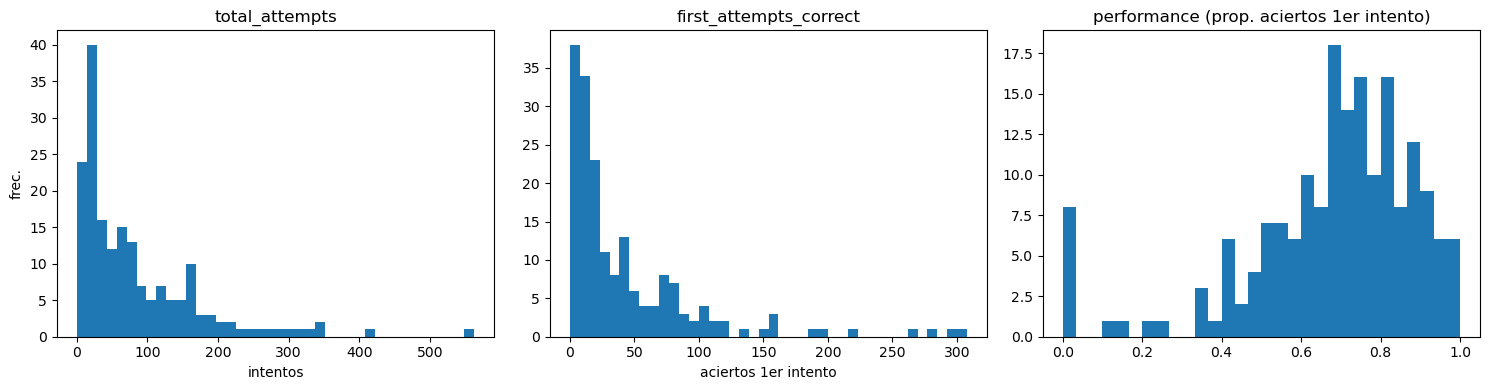

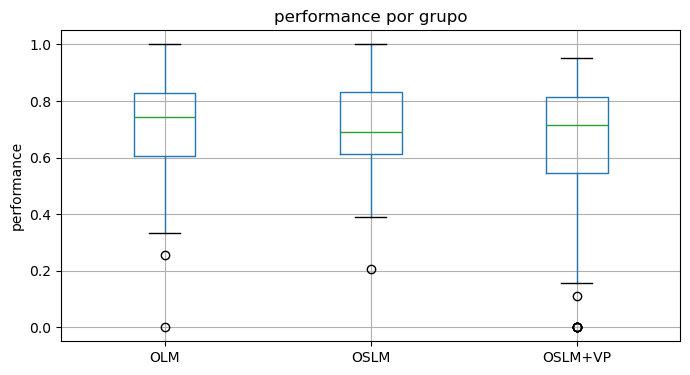


total_attempts por grupo:
                     count    mean     std    min     25%     50%      75%      max
grupo_intervencion                                                                 
OLM                59.0000 84.5760 95.7750 1.0000 22.5000 60.0000 119.5000 563.0000
OSLM               51.0000 87.2160 80.8740 2.0000 24.5000 65.0000 115.5000 344.0000
OSLM+VP            71.0000 78.1550 87.6380 0.0000 19.5000 39.0000 119.0000 419.0000

first_attempts_correct por grupo:
                     count    mean     std    min     25%     50%     75%      max
grupo_intervencion                                                                
OLM                59.0000 44.8470 65.2870 0.0000  8.5000 23.0000 50.0000 308.0000
OSLM               51.0000 44.2750 49.7340 2.0000 11.5000 23.0000 59.0000 219.0000
OSLM+VP            71.0000 41.7460 51.8430 0.0000  6.5000 19.0000 59.0000 268.0000

performance por grupo:
                     count   mean    std    min    25%    50%    75%    max
gru

In [13]:
def graficos_desempeno(df):
    df = df.copy()
    perf = pd.to_numeric(df["performance"], errors="coerce").dropna()
    ta   = pd.to_numeric(df["total_attempts"], errors="coerce").dropna()
    fac  = pd.to_numeric(df["first_attempts_correct"], errors="coerce").dropna()

    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    ax[0].hist(ta, bins=40);   ax[0].set(title="total_attempts", xlabel="intentos", ylabel="frec.")
    ax[1].hist(fac, bins=40);  ax[1].set(title="first_attempts_correct", xlabel="aciertos 1er intento")
    ax[2].hist(perf, bins=30, range=(0, 1)); ax[2].set(title="performance (prop. aciertos 1er intento)")
    plt.tight_layout(); plt.show()

    fig, ax = plt.subplots(figsize=(7, 4))
    df.boxplot(column="performance", by="grupo_intervencion", ax=ax)
    ax.set(title="performance por grupo", xlabel="", ylabel="performance"); plt.suptitle("")
    plt.tight_layout(); plt.show()

graficos_desempeno(dfUsuario)

for c in ["total_attempts", "first_attempts_correct", "performance"]:
    print(f"\n{c} por grupo:")
    print(dfUsuario.groupby("grupo_intervencion")[c].describe().round(3))

## 7. Revisión inversa — matriz de screening variable × factor

**Objetivo.** En vez de preguntar "¿el grupo afecta a la variable X?" una por una, aquí se recorre **cada variable de resultado** y se testea **cada factor** de forma sistemática, para producir una **tabla priorizada** de qué combinaciones muestran cambios y merecen un análisis dedicado.

**Factores evaluados:**
- `grupo` — 3 niveles (OLM / OSLM / OSLM+VP) para variables globales; **OSLM vs OSLM+VP** para variables que solo existen con comparación social.
- `direccion` de comparación (upward / downward / igual).
- `grupo × direccion` (interacción).

**Cómo se testea cada nivel:**
- *Variables de nivel usuario, factor grupo:* Kruskal–Wallis (3 grupos) o Mann–Whitney / Welch t (2 grupos) según supuestos, + epsilon² / eta² / rank-biserial.
- *Pares upward/abajo de nivel usuario (medida intra-sujeto, solo usuarios con casos en ambas direcciones):* Wilcoxon de rangos con signo para la dirección, Mann–Whitney para grupo (OSLM vs OSLM+VP) sobre el promedio por usuario, y Mann–Whitney sobre la diferencia (arriba − abajo) para la interacción.
- *Variables de nivel evento (`dfSegmento`, `dfNivelEjercicio`):* OLS sobre el **rango** de la variable (equivalente no paramétrico factorial) con **errores robustos por conglomerado** (usuario); el p de cada bloque (grupo, dirección, interacción) sale de un **Wald robusto por término**.

Todos los p se ajustan por **FDR (Benjamini–Hochberg)** dentro de cada bloque de screening. La columna `PRIORIDAD` combina significancia ajustada y magnitud del efecto.

### 7.1 Nivel usuario — factor `grupo`

> Se separan **variables globales** (definidas para los 3 grupos → contraste de 3 niveles) de las **variables que solo existen con comparación social** (`*_comparacion*`, `porce_topicos_*`, `preferencia_*`: en OLM son constantes por diseño). Para estas últimas, comparar los 3 grupos solo confirmaría el diseño; el contraste informativo es **OSLM vs OSLM+VP**.

In [14]:
OUTCOMES_GLOBALES = [
    "primer_pollValue", "autoeficacia_general", "casos", "total_attempts", "first_attempts_correct",
    "unique_steps", "performance", "Tasa_exito", "numero_hints", "tasa_hints",
    "numero_sesiones_diferentes", "tiempo_total_segundos", "selectionRating_result", "progreso_inicial",
]
OUTCOMES_SOLO_COMPARACION = [
    "preferencia_casos_comparacion", "preferencia_pasos_comparacion", "proporcion_casos_comparacion",
    "proporcion_steps_comparacion", "porce_topicos_arriba", "porce_topicos_abajo",
    "proporcion_casos_uw", "proporcion_casos_dw",
]

def screen_usuario_grupo(df):
    filas = []
    for v in OUTCOMES_GLOBALES:
        if v not in df.columns:
            continue
        r = contraste_k([df.loc[df.grupo_intervencion == g, v] for g in ORDEN_GRUPOS], variable=v)
        filas.append(dict(nivel="usuario", variable=v, factor="grupo (3)",
                          test=r["test"], stat=r["stat"], p=r["p"],
                          ef=r["ef"], ef_tipo=r["ef_tipo"], n=r["n"]))
    dc = df[df["grupo_intervencion"].isin(GRUPOS_COMP)]
    for v in OUTCOMES_SOLO_COMPARACION:
        if v not in df.columns:
            continue
        r = contraste_2(dc.loc[dc.grupo_intervencion == "OSLM", v],
                        dc.loc[dc.grupo_intervencion == "OSLM+VP", v], variable=v)
        filas.append(dict(nivel="usuario", variable=v, factor="grupo (OSLM vs OSLM+VP)",
                          test=r["test"], stat=r["stat"], p=r["p"],
                          ef=r["ef"], ef_tipo=r["ef_tipo"], n=r["n1"] + r["n2"]))
    t = pd.DataFrame(filas)
    t["p_fdr"] = ajustar_p(t["p"], "fdr_bh")
    t["magnitud"] = [magnitud(e, tp) for e, tp in zip(t["ef"], t["ef_tipo"])]
    return t

scr_71 = screen_usuario_grupo(dfUsuario)
print(scr_71.sort_values("p_fdr")[["variable", "factor", "test", "stat", "p", "p_fdr", "ef", "ef_tipo", "magnitud", "n"]]
      .round(4).to_string(index=False))

                     variable                  factor           test       stat      p  p_fdr      ef       ef_tipo magnitud   n
          proporcion_casos_dw grupo (OSLM vs OSLM+VP) Mann–Whitney U 2,263.5000 0.0144 0.1583 -0.2502 rank-biserial  pequeño 122
          porce_topicos_abajo grupo (OSLM vs OSLM+VP) Mann–Whitney U 2,263.5000 0.0144 0.1583 -0.2502 rank-biserial  pequeño 122
 proporcion_steps_comparacion grupo (OSLM vs OSLM+VP) Mann–Whitney U 2,051.0000 0.0348 0.1704 -0.2187 rank-biserial  pequeño 117
       selectionRating_result               grupo (3) Kruskal–Wallis     6.5030 0.0387 0.1704  0.0322      epsilon²  pequeño 172
preferencia_pasos_comparacion grupo (OSLM vs OSLM+VP) Mann–Whitney U 2,051.0000 0.0348 0.1704 -0.2187 rank-biserial  pequeño 117
 proporcion_casos_comparacion grupo (OSLM vs OSLM+VP) Mann–Whitney U 2,153.5000 0.0644 0.2025 -0.1895 rank-biserial  pequeño 122
preferencia_casos_comparacion grupo (OSLM vs OSLM+VP) Mann–Whitney U 2,153.5000 0.0644 0.2025 -0.

### 7.2 Nivel usuario — pares upward / downward (dirección, grupo y su interacción)

Cada usuario de OSLM/OSLM+VP aporta un valor `_arriba` y uno `_abajo` (medida intra-sujeto).

> **Corrección de ceros estructurales:** las columnas `*_arriba` / `*_abajo` se rellenaron con 0 cuando el usuario no tuvo casos en esa dirección. Aquí se restringe a usuarios con **≥1 caso en ambas direcciones** (`casos_comparacion_arriba>0` y `casos_comparacion_abajo>0`), para que la comparación arriba vs abajo sea entre valores realmente observados. Esto reduce el N.

In [15]:
PARES_DIR = [
    ("performance",              "performance_arriba",        "performance_abajo"),
    ("pasos_comparacion",        "pasos_comparacion_arriba",  "pasos_comparacion_abajo"),
    ("casos_comparacion",        "casos_comparacion_arriba",  "casos_comparacion_abajo"),
    ("tiempo_casos_comparacion", "tiempo_casos_comparacion_arriba", "tiempo_casos_comparacion_abajo"),
    ("tasa_exito_comparacion",   "tasa_exito_comparacion_arriba",   "tasa_exito_comparacion_abajo"),
    ("autoeficacia_prom_comp",   "autoeficacia_prom_comparacion_arriba", "autoeficacia_prom_comparacion_abajo"),
    ("rating_comparacion",       "rating_comparacion_arriba",  "rating_comparacion_abajo"),
]

def screen_usuario_direccion(df, pares):
    d = df[df["grupo_intervencion"].isin(GRUPOS_COMP)].copy()
    ca = pd.to_numeric(d["casos_comparacion_arriba"], errors="coerce").fillna(0)
    cb = pd.to_numeric(d["casos_comparacion_abajo"], errors="coerce").fillna(0)
    d = d[(ca > 0) & (cb > 0)].copy()
    print(f"Usuarios con casos en ambas direcciones: {len(d)} "
          f"({d['grupo_intervencion'].value_counts().to_dict()})")
    filas = []
    for base, c_up, c_dw in pares:
        if c_up not in d.columns or c_dw not in d.columns:
            continue
        sub = d[["userid", "grupo_intervencion", c_up, c_dw]].copy()
        sub[c_up] = pd.to_numeric(sub[c_up], errors="coerce")
        sub[c_dw] = pd.to_numeric(sub[c_dw], errors="coerce")
        par = sub.dropna(subset=[c_up, c_dw])
        if len(par) < 8:
            continue
        # (i) efecto dirección: Wilcoxon pareado arriba vs abajo
        try:
            w, p_dir = stats.wilcoxon(par[c_up], par[c_dw])
        except ValueError:
            w, p_dir = np.nan, np.nan
        n = len(par)
        # r pareado = Z / sqrt(N)
        if pd.notna(p_dir) and 0 < p_dir < 1:
            z = stats.norm.isf(p_dir / 2)
            r_dir = z / np.sqrt(n)
        else:
            r_dir = np.nan
        filas.append(dict(nivel="usuario", variable=base, factor="direccion (arriba vs abajo, pareado)",
                          test="Wilcoxon", stat=w, p=p_dir, ef=r_dir, ef_tipo="r", n=n))
        # (ii) efecto grupo: MW sobre promedio (arriba, abajo) por usuario
        par = par.assign(_media=(par[c_up] + par[c_dw]) / 2, _dif=par[c_up] - par[c_dw])
        r_g = contraste_2(par.loc[par.grupo_intervencion == "OSLM", "_media"],
                          par.loc[par.grupo_intervencion == "OSLM+VP", "_media"], variable=base)
        filas.append(dict(nivel="usuario", variable=base, factor="grupo (OSLM vs OSLM+VP)",
                          test=r_g["test"], stat=r_g["stat"], p=r_g["p"],
                          ef=r_g["ef"], ef_tipo=r_g["ef_tipo"], n=r_g["n1"] + r_g["n2"]))
        # (iii) interacción: MW sobre la diferencia (arriba - abajo) por usuario
        r_i = contraste_2(par.loc[par.grupo_intervencion == "OSLM", "_dif"],
                          par.loc[par.grupo_intervencion == "OSLM+VP", "_dif"], variable=base)
        filas.append(dict(nivel="usuario", variable=base, factor="grupo × direccion",
                          test=r_i["test"], stat=r_i["stat"], p=r_i["p"],
                          ef=r_i["ef"], ef_tipo=r_i["ef_tipo"], n=r_i["n1"] + r_i["n2"]))
    t = pd.DataFrame(filas)
    t["p_fdr"] = ajustar_p(t["p"], "fdr_bh")
    t["magnitud"] = [magnitud(e, tp) for e, tp in zip(t["ef"], t["ef_tipo"])]
    return t

scr_72 = screen_usuario_direccion(dfUsuario, PARES_DIR)
print(scr_72.sort_values("p_fdr")[["variable", "factor", "test", "stat", "p", "p_fdr", "ef", "ef_tipo", "magnitud", "n"]]
      .round(4).to_string(index=False))

Usuarios con casos en ambas direcciones: 42 ({'OSLM+VP': 24, 'OSLM': 18, 'OLM': 0})
                variable                               factor           test     stat      p  p_fdr      ef       ef_tipo magnitud  n
  tasa_exito_comparacion direccion (arriba vs abajo, pareado)       Wilcoxon 119.0000 0.0067 0.1407  0.4720             r  mediano 33
             performance                    grupo × direccion Mann–Whitney U 121.0000 0.0163 0.1711  0.4398 rank-biserial  mediano 42
             performance direccion (arriba vs abajo, pareado)       Wilcoxon 366.0000 0.7377 0.8698  0.0517             r  trivial 42
      rating_comparacion direccion (arriba vs abajo, pareado)       Wilcoxon  63.0000 0.5227 0.8698  0.1167             r  pequeño 30
  autoeficacia_prom_comp                    grupo × direccion Mann–Whitney U  93.0000 0.5391 0.8698  0.1389 rank-biserial  pequeño 30
  autoeficacia_prom_comp              grupo (OSLM vs OSLM+VP)        Welch t  -0.3386 0.7383 0.8698 -0.1285     

### 7.3 Nivel evento — `grupo`, `direccion` y `grupo × direccion` (OLS robusto sobre rangos)

Para cada variable se ajusta `rango(variable) ~ C(grupo) * C(direccion)` por OLS con errores robustos por conglomerado (usuario). El p de cada bloque es el **Wald robusto del término** (`wald_test_terms`); `ef ≈ R²(≈)` = `stat/(stat+N)`, solo para ordenar. En `dfSegmento` la dirección (`arriba` / `abajo` / `igual`) se evalúa dentro de OSLM ∪ OSLM+VP (en OLM siempre es `no`). En `dfNivelEjercicio` la dirección es la posición objetiva (existe para los 3 grupos) pero viene **propagada por usuario con ffill/bfill** (proxy ruidoso) y la categoría `igual` está vacía en OLM → se usa solo `arriba` / `abajo`.

In [16]:
def _fila_evento(nivel, v, factor, res, termino, n):
    w = res.wald_test_terms(scalar=True).summary_frame()
    w.columns = [str(c) for c in w.columns]
    statcol = next(c for c in w.columns if c.lower() in ("f", "chi2", "statistic"))
    pcol = next(c for c in w.columns if c.lower().startswith("p"))
    stat = float(w.loc[termino, statcol]); p = float(w.loc[termino, pcol])
    ef = stat / (stat + n) if (stat + n) else np.nan          # R²(≈) parcial, solo para ordenar
    return dict(nivel=nivel, variable=v, factor=factor, test="Wald robusto (rango)",
                stat=stat, p=p, ef=ef, ef_tipo="R²(≈)", n=n)

def screen_evento(df, outcomes, etiqueta, direccion_confundida_con_OLM, dir_niveles=("arriba", "abajo", "igual")):
    filas = []
    d = df.copy()
    d["grupo_intervencion"] = d["grupo_intervencion"].astype(str)
    d["direccion"] = d["direccion"].where(d["direccion"].isin(dir_niveles))
    for v in outcomes:
        if v not in d.columns:
            continue
        sv = d[["userid", "grupo_intervencion", "direccion", v]].copy()
        sv[v] = pd.to_numeric(sv[v], errors="coerce")

        # --- efecto grupo (3 niveles, sin filtrar por dirección) ---
        sg = sv.dropna(subset=["grupo_intervencion", v]).copy()
        if sg["userid"].nunique() >= 10 and len(sg) >= 40 and sg["grupo_intervencion"].nunique() >= 2:
            sg["rango"] = sg[v].rank()
            try:
                r = smf.ols("rango ~ C(grupo_intervencion)", sg).fit(
                    cov_type="cluster", cov_kwds={"groups": sg["userid"].astype(str)})
                filas.append(_fila_evento(etiqueta, v, "grupo (3)", r, "C(grupo_intervencion)", len(sg)))
            except Exception as e:
                print(f"  [aviso] {etiqueta}/{v}/grupo: {type(e).__name__}: {e}")

        # --- dirección e interacción ---
        sd = sv.dropna(subset=["direccion", v]).copy()
        if direccion_confundida_con_OLM:
            sd = sd[sd["grupo_intervencion"].isin(GRUPOS_COMP)]
        celdas = pd.crosstab(sd["grupo_intervencion"], sd["direccion"])
        rango_completo = (celdas.values >= 5).all() and celdas.shape[1] >= 2
        if sd["userid"].nunique() >= 10 and len(sd) >= 40 and rango_completo:
            sd["rango"] = sd[v].rank()
            multi_g = sd["grupo_intervencion"].nunique() >= 2
            f = ("rango ~ C(grupo_intervencion) * C(direccion)" if multi_g
                 else "rango ~ C(direccion)")
            try:
                r = smf.ols(f, sd).fit(cov_type="cluster",
                                       cov_kwds={"groups": sd["userid"].astype(str)})
                filas.append(_fila_evento(etiqueta, v, "direccion", r, "C(direccion)", len(sd)))
                if multi_g:
                    filas.append(_fila_evento(etiqueta, v, "grupo × direccion", r,
                                              "C(grupo_intervencion):C(direccion)", len(sd)))
            except Exception as e:
                print(f"  [aviso] {etiqueta}/{v}/direccion: {type(e).__name__}: {e}")
    t = pd.DataFrame(filas)
    if not t.empty:
        t["p_fdr"] = ajustar_p(t["p"], "fdr_bh")
        t["magnitud"] = [magnitud(e, tp) for e, tp in zip(t["ef"], t["ef_tipo"])]
    return t

scr_seq = screen_evento(dfSegmento,
                        ["pollValue", "pollValue_next", "delta_pollValue", "total_attempts",
                         "first_attempts_correct", "prop_first_attempts_correct", "unique_steps",
                         "selectionRating_result"],
                        "evento:dfSegmento", direccion_confundida_con_OLM=True)
scr_niv = screen_evento(dfNivelEjercicio,
                        ["first_attempts_correct", "prop_first_attempts_correct", "total_attempts",
                         "total_hints", "unique_steps", "duracion_segundos", "selectionRating_result",
                         "pollValue_num"],
                        "evento:dfNivelEjercicio", direccion_confundida_con_OLM=False,
                        dir_niveles=("arriba", "abajo"))  # 'igual' casi ausente y vacío en OLM -> matriz singular

for nombre, t in [("dfSegmento", scr_seq), ("dfNivelEjercicio", scr_niv)]:
    print(f"\n=== {nombre} ===")
    if t.empty:
        print("  (sin resultados)")
    else:
        print(t.sort_values("p_fdr")[["variable", "factor", "stat", "p", "p_fdr", "ef", "magnitud", "n"]]
              .round(4).to_string(index=False))


=== dfSegmento ===
                   variable            factor    stat      p  p_fdr     ef magnitud   n
            delta_pollValue grupo × direccion 10.1671 0.0062 0.1488 0.0307  pequeño 321
            delta_pollValue         grupo (3)  7.2007 0.0273 0.2121 0.0154  pequeño 461
               unique_steps         direccion  7.0720 0.0291 0.2121 0.0128  pequeño 547
     first_attempts_correct         direccion  6.6848 0.0354 0.2121 0.0121  pequeño 547
     selectionRating_result grupo × direccion  5.0539 0.0799 0.2968 0.0096  trivial 524
             pollValue_next         direccion  4.6634 0.0971 0.2968 0.0143  pequeño 321
            delta_pollValue         direccion  4.8997 0.0863 0.2968 0.0150  pequeño 321
     selectionRating_result         direccion  4.6267 0.0989 0.2968 0.0088  trivial 524
                  pollValue         direccion  2.8247 0.2436 0.6495 0.0051  trivial 547
                  pollValue grupo × direccion  2.4371 0.2957 0.7096 0.0044  trivial 547
            

### 7.4 Tabla consolidada y priorización

In [17]:
COLS = ["nivel", "variable", "factor", "test", "stat", "p", "p_fdr", "ef", "ef_tipo", "magnitud", "n"]
consolidado = pd.concat([d for d in [scr_71, scr_72, scr_seq, scr_niv] if not d.empty],
                        ignore_index=True)[COLS]

def prioridad(row):
    if pd.isna(row["p_fdr"]):
        return "—"
    if row["p_fdr"] < .05:
        if row["magnitud"] in ("mediano", "grande"):
            return "ALTA"
        if row["magnitud"] == "pequeño":
            return "media"
        return "detectable, efecto trivial"
    if row["p"] < .05:
        return "revisar (no sobrevive FDR)"
    return "baja"

_ORD = {"ALTA": 0, "media": 1, "revisar (no sobrevive FDR)": 2,
        "detectable, efecto trivial": 3, "baja": 4, "—": 5}
consolidado["PRIORIDAD"] = consolidado.apply(prioridad, axis=1)
consolidado = consolidado.sort_values(
    ["PRIORIDAD", "p_fdr"],
    key=lambda c: c.map(_ORD) if c.name == "PRIORIDAD" else c)
print("=== MATRIZ DE SCREENING (ordenada por prioridad) ===\n")
print(consolidado.round(4).to_string(index=False))

print("\n--- Combinaciones de PRIORIDAD ALTA (merecen análisis dedicado) ---")
alta = consolidado[consolidado["PRIORIDAD"] == "ALTA"]
if alta.empty:
    print("  Ninguna combinación variable × factor alcanza prioridad ALTA.")
else:
    for _, r in alta.iterrows():
        print(f"  • [{r['nivel']}] {r['variable']}  —  {r['factor']}: "
              f"{r['test']}, p_fdr={r['p_fdr']:.4f}, {r['ef_tipo']}={r['ef']:.3f} ({r['magnitud']})")

=== MATRIZ DE SCREENING (ordenada por prioridad) ===

                  nivel                      variable                               factor                 test       stat      p  p_fdr      ef       ef_tipo magnitud    n                  PRIORIDAD
evento:dfNivelEjercicio             duracion_segundos                    grupo × direccion Wald robusto (rango)     8.2806 0.0159 0.1167  0.0017         R²(≈)  trivial 4873 revisar (no sobrevive FDR)
evento:dfNivelEjercicio        selectionRating_result                            direccion Wald robusto (rango)     6.1200 0.0134 0.1167  0.0014         R²(≈)  trivial 4398 revisar (no sobrevive FDR)
                usuario        tasa_exito_comparacion direccion (arriba vs abajo, pareado)             Wilcoxon   119.0000 0.0067 0.1407  0.4720             r  mediano   33 revisar (no sobrevive FDR)
      evento:dfSegmento               delta_pollValue                    grupo × direccion Wald robusto (rango)    10.1671 0.0062 0.1488  0.0307  

### 7.5 Mapa de calor variable × factor

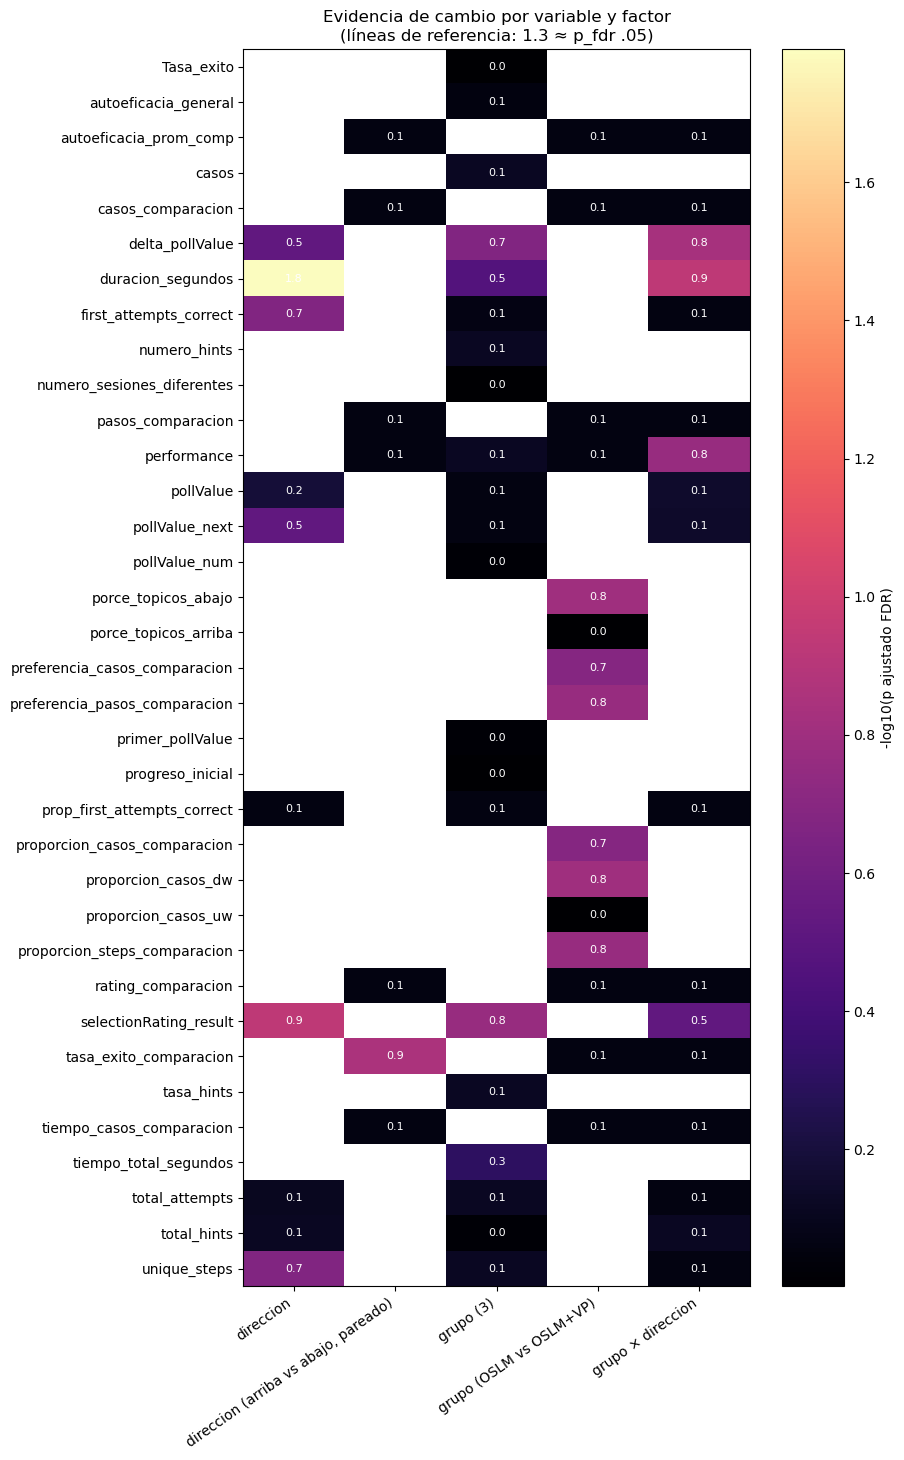

In [18]:
piv = (consolidado.assign(signif=lambda d: -np.log10(d["p_fdr"].clip(lower=1e-6)))
       .pivot_table(index="variable", columns="factor", values="signif", aggfunc="max"))

fig, ax = plt.subplots(figsize=(9, max(4, 0.42 * len(piv))))
im = ax.imshow(piv.values, aspect="auto", cmap="magma")
ax.set_xticks(range(piv.shape[1])); ax.set_xticklabels(piv.columns, rotation=35, ha="right")
ax.set_yticks(range(piv.shape[0])); ax.set_yticklabels(piv.index)
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        val = piv.values[i, j]
        if pd.notna(val):
            ax.text(j, i, f"{val:.1f}", ha="center", va="center",
                    color="white" if val < 2 else "black", fontsize=8)
cb = plt.colorbar(im, ax=ax); cb.set_label("-log10(p ajustado FDR)")
ax.set_title("Evidencia de cambio por variable y factor\n(líneas de referencia: 1.3 ≈ p_fdr .05)")
plt.tight_layout(); plt.show()

### 7.6 Lectura de la revisión inversa

- **ALTA** → sobrevive la corrección FDR y con magnitud ≥ mediana. Modelar en detalle (modelo dedicado, post-hoc, control de covariables, supuestos y casos influyentes).
- **media** → significativo tras FDR con efecto pequeño: reportar con cautela sobre su relevancia práctica.
- **detectable, efecto trivial** → p ajustado < .05 pero magnitud despreciable (típico de N grande, p. ej. la dirección *ffilleada* en `dfNivelEjercicio`): probablemente no interpretable.
- **revisar (no sobrevive FDR)** → p < .05 sin corregir; posible ruido por comparaciones múltiples. Seguir solo si hay hipótesis previa **o** un test focalizado bien especificado lo confirma.

El screening usa tests de rango y aproximaciones (Wald robusto, R²≈) pensados para **triaje**, no como resultado final. Cada combinación priorizada debe re-analizarse con el modelo adecuado.

**Síntesis de esta corrida** (con los datos ya corregidos: 86 usuarios y 809 filas en `dfSegmento`, sin filas autorreferenciadas ni usuarios outlier contaminando la muestra): ninguna combinación llega a ALTA — igual que antes de corregir el preprocesamiento. Las señales que aparecen de forma repetida (sin corregir) y que se re-analizan en §3.4 y §4:
1. **Cambio de autoeficacia según grupo** — en el screening figura como *revisar*; al re-analizarlo bien (§3.4, una observación por usuario) el efecto es débil y ya **no llega a borderline**: KW por usuario p ≈ .31 (antes ≈ .19), ANCOVA ajustando por basal OSLM vs OLM p ≈ .11 (antes ≈ .05), interacción tiempo×grupo del modelo de crecimiento p ≈ .14 (antes ≈ .05). La señal es más débil que en la corrida con los datos sin corregir — consistente con que parte de esa señal previa era artefacto de las 48 transiciones corruptas y las 134 filas de usuarios outlier que se colaban en `dfSegmento` antes del fix.
2. **Selección de contenido con comparación social entre OSLM y OSLM+VP** (`porce_topicos_abajo` / `proporcion_casos_dw`, y la variable binaria *nunca eligió un caso con comparación*: 46 % OSLM+VP vs 29 % OSLM) — p sin corregir ≈ .06–.09 (antes ≈ .01–.05), efecto pequeño, **no sobrevive** la corrección; también se debilitó tras la limpieza de datos.
3. **Desempeño por dirección × grupo** (§7.2, usuarios con casos en ambas direcciones, n = 42) — efecto mediano (rank-biserial ≈ .44, p ≈ .016) pero el efecto principal de dirección es nulo (Wilcoxon p ≈ .74) y no sobrevive FDR (p_fdr ≈ .17): sigue siendo, como antes de la corrección, solo una hipótesis a explorar con más datos.

## 8. Síntesis de hallazgos y de correcciones aplicadas

### Hallazgos
- **Equilibrio basal.** Los tres grupos son equivalentes en autoeficacia inicial
  (`primer_pollValue`, KW p ≈ .73) → la aleatorización funcionó. (Sin cambios.)
- **Autoeficacia sube con el tiempo (robusto).** En el modelo de crecimiento
  `pollValue ~ tiempo × grupo` (RE por usuario, ICC ≈ .62) el efecto de tiempo es grande y muy
  significativo: **+11.8 puntos por medición** (χ²(1) ≈ 8.65, p ≈ .003). Vale para los tres
  grupos. (Antes: +9.6 pts, p ≈ .005 — con los datos corregidos el efecto es, si acaso, algo más
  fuerte; conclusión sin cambios.)
- **Diferencias de grupo en el cambio: no robustas, y más débiles que antes de corregir los
  datos.** (a) KW sobre Δautoeficacia **por usuario** (1 dato/persona, n=82): p ≈ .31 (antes ≈
  .19). (b) ANCOVA ajustando por autoeficacia basal real (`primer_pollValue` de `dfUsuario`,
  corregido en esta revisión — antes se usaba una aproximación por orden alfabético de tópico
  que solo coincidía en 23/86 casos): OSLM vs OLM = −3.9 pts, p ≈ .11 (antes: −5.5 pts, p ≈ .05,
  "borderline"). (c) Interacción tiempo × grupo: Wald ómnibus p ≈ .14 (antes ≈ .05); el
  coeficiente de OSLM+VP ya no se acerca a significativo (p ≈ .20, antes ≈ .02). **Ninguna de
  las tres especificaciones sugiere ya siquiera un efecto borderline.** Esto es evidencia de que
  parte de la señal "borderline" observada antes de la auditoría de preprocesamiento era
  artefacto de las transiciones corruptas / usuarios outlier contaminando `dfSegmento`, no una
  señal real que la corrección de datos haya "destruido" — es el resultado esperable de sacar
  ruido de la muestra. El KW p ≈ .001 del notebook *original* (antes de cualquier corrección)
  era pseudorreplicación (≈490 transiciones no independientes).
- **Contrastes de grupo en el modelo autorregresivo** (`pollValue_next ~ …`, dfSegmento
  completo y por transición D1→D2 / D2→D3): no significativos en ningún caso (todos p > .15).
  El contraste D2→D3 (OSLM+VP vs OSLM), que antes aparecía borderline (p ≈ .07), ahora da p ≈
  .15. Predictor dominante y estable en todas las especificaciones: la autoeficacia previa
  (`pollValue`, coef ≈ 17–21 pts por DE, p < .0001).
- **Selección de subtópicos (Pregunta 3.1).** Entre OSLM y OSLM+VP: `porce_topicos_abajo` /
  `proporcion_casos_dw` (medianas 0.33 vs 0.00) y la variable binaria *nunca eligió un caso con
  comparación* (46 % OSLM+VP vs 29 % OSLM; se agregó el test formal — chi² = 2.94, p ≈ .086,
  Fisher exacto p ≈ .063) van en la misma dirección, con p sin corregir ≈ .06–.09 (antes ≈
  .01–.05) y efecto pequeño; **no sobreviven** Holm (p_holm ≈ .10–.43). `progreso_inicial` no
  difiere entre grupos (p ≈ .95). **Advertencia (sin cambios):** estas variables dependen en
  parte del nº de casos hechos (OSLM+VP hizo algo menos), así que no son elección "pura".
- **Desempeño (Pregunta 3.2).** `performance` global no difiere entre grupos (KW p ≈ .44, sin
  cambios). El aparente efecto de `performance_abajo` (OSLM > OSLM+VP) en la versión *sin
  condicionar* (con los ceros estructurales) da p ≈ .03 (p_holm ≈ .07); al restringir a usuarios
  con casos reales en esa dirección (condicional, n=35 vs 35) el efecto **desaparece** (p ≈
  .63): confirma que era artefacto de los ceros estructurales, no una diferencia real. *(Nota:
  la síntesis previa citaba "n baja de 122 a 42" — esa cifra de 42 corresponde a un análisis
  distinto, §7.2, que exige casos en AMBAS direcciones; el análisis condicional de esta sección
  exige solo casos en la dirección evaluada y queda en n=35+35=70.)*
- **Revisión inversa (§7).** Ninguna combinación variable × factor alcanza prioridad ALTA tras
  FDR — igual que antes de corregir los datos; es la conclusión más robusta de todo el
  documento, y no cambió con la corrección.
- **Limitaciones de potencia (sin cambios sustantivos).** Solo 105/181 usuarios tienen
  autoeficacia medida y solo 82 aparecen con Δ (27/27/28 por grupo); los análisis por dirección
  se apoyan en 42 usuarios (con casos en ambas direcciones). Los resultados nulos deben leerse
  como *no detectamos efecto*, no como *no hay efecto*.
